In [1]:
import os
import sys
import numpy as np
import seaborn as sns
import pandas as pd

from matplotlib import pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

from scipy.stats import levene
from pingouin import welch_anova, pairwise_gameshowell

In [2]:
import sys

sys.path.append("../utils")

import data_io

# setup

In [3]:
cm = 1/2.54  # centimeters in inches
plt.style.use('paper.mplstyle')
MIN_FLOAT = sys.float_info.min

In [4]:
order =[ 't1','GluMI','t2', 
        't3a', 't3b',  't4', 't5i', 't5o', 't5t', 'XBC',
        't6', 't7', 't8', 't9','RBC']

In [5]:
cell_type_colors = {'t1': '#da3b3c',
 'GluMI': '#1b75ab',
 't2': '#ffcad4',
 't3a': '#8d86b8',
 't3b': '#f0a54c',
 't4': '#6ca46c',
 't5o': '#0c7c5a',
 't5t': '#e0b0c8',
 't5i': '#487bb9',
 'XBC': '#e5603a',
 't7': '#ecc56f',
 't6': '#137983',
 't8': '#c195bc',
 't9': '#ef8538',
 'RBC': '#cacc7f'}
  

In [6]:
GROUPS = {
    'OFF CBCs': ['t1', 'GluMI', 't2', 't3a', 't3b', 't4'],
    'ON CBCs':  ['t5i', 't5o', 't5t', 'XBC', 't6', 't7', 't8', 't9']
}

# plot functions

In [7]:
# boxplots

def _add_xaxis_brackets(ax, order, groups):
    fig = ax.get_figure()
    tick_pos = {label: i for i, label in enumerate(order)}

    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    min_label_y = np.inf
    for tick in ax.get_xticklabels():
        bb = tick.get_window_extent(renderer)
        if bb.y0 < min_label_y:
            min_label_y = bb.y0

    inv = ax.transAxes.inverted()
    _, bracket_y_ax = inv.transform((0, min_label_y))
    bracket_y_ax -= 0.12
    tick_y_ax     = bracket_y_ax + 0.025
    label_y_ax    = bracket_y_ax - 0.12

    def data_x_to_ax(xi):
        x_min, x_max = ax.get_xlim()
        return (xi - x_min) / (x_max - x_min)

    for group_name, members in groups.items():
        present = [m for m in members if m in tick_pos]
        if not present:
            continue

        i0, i1 = tick_pos[present[0]], tick_pos[present[-1]]
        x0_ax, x1_ax = data_x_to_ax(i0), data_x_to_ax(i1)
        xm_ax = (x0_ax + x1_ax) / 2
        pad, lw = 0.012, 0.8
        trans = ax.transAxes

        ax.plot([x0_ax - pad, x1_ax + pad], [bracket_y_ax, bracket_y_ax],
                transform=trans, color='black', lw=lw, clip_on=False, solid_capstyle='butt')
        ax.plot([x0_ax - pad, x0_ax - pad], [bracket_y_ax, tick_y_ax],
                transform=trans, color='black', lw=lw, clip_on=False, solid_capstyle='butt')
        ax.plot([x1_ax + pad, x1_ax + pad], [bracket_y_ax, tick_y_ax],
                transform=trans, color='black', lw=lw, clip_on=False, solid_capstyle='butt')
        ax.text(xm_ax, label_y_ax, group_name,
                transform=trans, ha='center', va='top',
                clip_on=False)


def plot_boxplot(data, x, y, order, ylabel, title='',
                 figsize=(10 * cm, 8 * cm), show_points=True,
                 hue=None, palette=None):

    fig, ax = plt.subplots(figsize=figsize)

    box_width = 0.5   

    sns.boxplot(
        data=data, x=x, y=y, order=order,
        hue=hue if hue else x,
        palette=cell_type_colors,
        linewidth=0,
        width=box_width,
        whis=1,
        showfliers=False,
        medianprops=dict(linewidth=0),   # hide seaborn's median; redrawn below
        boxprops=dict(edgecolor='none'),
        whiskerprops=dict(linewidth=.5, color='lightgrey', linestyle='-'),
        capprops=dict(linewidth=.5, color='lightgrey'),
        flierprops = dict(marker='o', markerfacecolor='None', markersize=.5,  markeredgecolor='lightgrey'),
        ax=ax,
        legend = False
    )

    # ── Set box alpha ──────────────────────────────────────────────────────────
    for patch in ax.patches:
        if isinstance(patch, mpatches.FancyBboxPatch):
            continue
        patch.set_alpha(0.5)

    # ── Redraw median lines from tick index, not patch geometry ────────────────
    # When hue == x (one hue level per cell type, no dodging), each cell type's
    # box centre sits exactly at its integer tick index.
    half_w  = box_width / 2
    med_ext = 0.08   # how much the median line extends beyond each box edge

    for i, label in enumerate(order):
        col_data = data.loc[data[x] == label, y].dropna()
        if col_data.empty:
            continue
        median_val = col_data.median()
        color = cell_type_colors.get(label, 'grey')

        ax.plot([i - half_w - med_ext, i + half_w + med_ext],
                [median_val, median_val],
                color=color, lw=1.5, solid_capstyle='butt',
                zorder=5, transform=ax.transData)

    if show_points:
        # Up to 200 points per cell type
        sampled = (
            data.groupby(x, group_keys=False)
                .apply(lambda g: g.sample(n=min(100, len(g)), random_state=0))
        )

        sns.stripplot(
            data=sampled, x=x, y=y, order=order,
            hue=x, palette=cell_type_colors,
            size=1, alpha=0.4,
            jitter=True, legend=False, ax=ax,
        )

    # ── Draw subsampled outliers manually ─────────────────────────────────────────
    n_fliers = 20   # max outliers shown per cell type
    
    for i, label in enumerate(order):
        col_data = data.loc[data[x] == label, y].dropna()
        if col_data.empty:
            continue
        q1, q3 = col_data.quantile(0.25), col_data.quantile(0.75)
        iqr = q3 - q1
        outliers = col_data[(col_data < q1 - 1 * iqr) | (col_data > q3 + 1 * iqr)]
        if outliers.empty:
            continue
        if len(outliers) > n_fliers:
            outliers = outliers.sample(n=n_fliers, random_state=0)
        jitter = np.random.default_rng(0).uniform(-0.2, 0.2, size=len(outliers))
        ax.scatter(i + jitter, outliers,
                   marker='o', s=0.5,
                   facecolors='none', edgecolors='lightgrey',
                   linewidths=0.3, zorder=2)

    ax.set_xlabel('')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.tick_params(axis='x', labelsize=8,rotation=55)
    ax.tick_params(axis='y', labelsize=8)
    
    if y == 'size':
        ax.ticklabel_format(axis='y', style='sci', scilimits=(-2, -2), useMathText=True)
        ax.set_ylabel(r'Size $[10^{-2}\ \mu m^3]$')
        ax.set_yticks([3e-3, 7e-3, 1e-2])
        # ax.set_yticklabels(['0', '1'])
    else:
        ax.set_ylabel(ylabel)
        ax.set_yticks([100,200, 300])

    sns.despine(trim=True)
    _add_xaxis_brackets(ax, order, GROUPS)

    plt.tight_layout()
    fig.subplots_adjust(bottom=0.45)

    return fig


In [8]:
# ridgeplot

def _add_yaxis_brackets(fig, g, order, groups, fontsize=8):
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    
    row_order = list(reversed(order))
    label_to_idx = {label: i for i, label in enumerate(row_order)}

    fig_bb = fig.get_window_extent(renderer)

    def to_fig(px, py):
        return ((px - fig_bb.x0) / fig_bb.width,
                (py - fig_bb.y0) / fig_bb.height)

    # Find the leftmost edge of all label texts across all axes
    min_text_x = np.inf
    for ax in g.axes.flat:
        for artist in ax.get_children():
            if isinstance(artist, plt.Text) and artist.get_text():
                bb = artist.get_window_extent(renderer)
                if bb.x0 < min_text_x:
                    min_text_x = bb.x0

    bracket_x  = min_text_x - 10   # px gap between bracket and labels
    tick_len =5   # was 5, smaller looks cleaner
    
    for group_name, members in groups.items():
        present = [m for m in members if m in label_to_idx]
        if not present:
            continue

        idx_top = label_to_idx[present[0]]
        idx_bot = label_to_idx[present[-1]]

        bb_top = g.axes.flat[idx_top].get_window_extent(renderer)
        bb_bot = g.axes.flat[idx_bot].get_window_extent(renderer)

        row_h  = bb_top.height   # one row height in px

        # Centre ± extend by half a row so bracket captures the full first/last row
        y_top = (bb_top.y0 + bb_top.y1) / 2 - row_h * 0.05
        y_bot = (bb_bot.y0 + bb_bot.y1) / 2 - row_h * 0.4
        y_mid = (y_top + y_bot) / 2
        pad = 1

        x0f,  y_topf = to_fig(bracket_x, y_top - pad)
        _,    y_botf = to_fig(bracket_x, y_bot + pad)
        _,    y_midf = to_fig(bracket_x, y_mid)
        x1f,  _      = to_fig(bracket_x + tick_len, y_mid)


        # Vertical bar
        fig.add_artist(plt.Line2D([x0f, x0f], [y_botf, y_topf],
                                  transform=fig.transFigure,
                                  color='black', lw=0.8, clip_on=False))
        
        # Top tick — point RIGHT (toward labels)
        fig.add_artist(plt.Line2D([x0f, x1f], [y_topf, y_topf],
                                  transform=fig.transFigure,
                                  color='black', lw=0.8, clip_on=False))
        
        # Bottom tick — point RIGHT
        fig.add_artist(plt.Line2D([x0f, x1f], [y_botf, y_botf],
                                  transform=fig.transFigure,
                                  color='black', lw=0.8, clip_on=False))

        
        # Rotated group label
        x_textf, _ = to_fig(bracket_x - tick_len - 4, y_mid)
        fig.text(x_textf, y_midf, group_name,
                 ha='right', va='center', fontsize=fontsize,
                 rotation=90, transform=fig.transFigure, clip_on=False)


    
def plot_ridgeplot(data, x, y, order, xlabel, title='',
                   aspect=12, height=0.8*cm, bw_adjust=0.5,
                   xlim=None, xticks=None, xticklabels=None, fontsize = 8):

    plot_df = data[[x, y]].copy()
    plot_df = plot_df[plot_df[x].isin(order)].copy()
    plot_df[x] = pd.Categorical(plot_df[x], categories=order[::-1], ordered=True)
    plot_df = plot_df.sort_values(x)

    pal = {label: cell_type_colors.get(label, 'grey') for label in order}

    g = sns.FacetGrid(
        plot_df, row=x, hue=x,
        aspect=aspect, height=height,
        palette=pal,
    )

    g.map(sns.kdeplot, y,
          bw_adjust=bw_adjust, clip_on=False,
          fill=True, alpha=1, linewidth=0)

    g.map(sns.kdeplot, y,
          bw_adjust=bw_adjust, clip_on=False,
          color='white', lw=1.2)

    g.refline(y=0, linewidth=0.8, linestyle='-', color='white', clip_on=False)

    # ── Labels in black (no color) ─────────────────────────────────────────────
    def label(data, color, label):
        ax = plt.gca()
        ax.text(-0.01, 0.2, label,
                color='black', ha='right', va='center',
                transform=ax.transAxes,
                fontsize=fontsize)
    g.map(label, y)

    # ── x-axis ────────────────────────────────────────────────────────────────
    for i, ax in enumerate(g.axes.flat):
        ax.set_facecolor('none')  # or 'transparent'
        if xlim is not None:
            ax.set_xlim(xlim)
        if xticks is not None:
            ax.set_xticks(xticks)
        if i == len(g.axes.flat) - 1:
            if xticklabels is not None:
                ax.set_xticklabels(xticklabels)
            ax.tick_params(axis='x', bottom=True, labelbottom=True)
        else:
            ax.tick_params(axis='x', bottom=False, labelbottom=False)

    g.figure.subplots_adjust(hspace=-0.6)
    g.set_titles('')
    g.set(yticks=[], ylabel='')
    g.set_axis_labels(xlabel, '')
    g.despine(bottom=False, left=True)

    # ── Y-axis brackets ────────────────────────────────────────────────────────
    _add_yaxis_brackets(g.figure, g, order, GROUPS, fontsize=8)

    if title:
        g.figure.suptitle(title, y=1.01)

    return g

In [9]:
# p-values ans effect sizes

def fmt_pval(p):
    if pd.isna(p):                return ""
    if p == 0 or p <= MIN_FLOAT:  return f">{MIN_FLOAT:.1e}"
    if p < 0.001:                 return f"{p:.2e}"
    return f"{p:.3f}"

def fmt_cohen(d):
    if pd.isna(d): return ""
    return f"{d:+.2f}"

def sig_int(p):
    if pd.isna(p):  return np.nan
    if p <= 0.001:  return 3.0
    if p <= 0.01:   return 2.0
    if p <= 0.05:   return 1.0
    return 0.0

# Discrete colormap for p-values
P_COLORS = ["#D6E8F5", "#6BAED6", "#2171B5", "#08306B"]
p_cmap   = mcolors.ListedColormap(P_COLORS)
p_norm   = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], p_cmap.N)

LEGEND_HANDLES = [
    mpatches.Patch(facecolor=c, edgecolor='#aaa', linewidth=0.4, label=l)
    for c, l in zip(P_COLORS, ["ns", "* p≤0.05", "** p≤0.01", "*** p≤0.001"])
]

def build_pivot_matrices(results, order):
    # Upper-triangle pivots directly from results
    p_upper = results.pivot(index='A', columns='B', values='pval')
    d_upper = results.pivot(index='A', columns='B', values='cohen')

    # Reindex to full square — lower triangle stays NaN (hidden for p-values)
    p_full = p_upper.reindex(index=order, columns=order)
    d_full = d_upper.reindex(index=order, columns=order)

    # Fill lower triangle of Cohen's d with flipped sign via transposed combine
    d_full  = d_full.combine_first(-1*d_full.T)
    p_full = p_full.combine_first(p_full.T)


    sig_full = p_full.map(sig_int)
    annot_p  = p_full.map(fmt_pval)
    annot_d  = d_full.map(fmt_cohen)

    n       = len(order)
    # mask = np.triu(np.ones_like(p_full, dtype=bool), k=1)  # upper triangle WITHOUT diagonal
    mask_p  = np.tril(np.ones((n, n), dtype=bool))  # hide lower tri + diag
    mask_d  = np.eye(n, dtype=bool)                  # hide diagonal only

    return sig_full, d_full, annot_p, annot_d, mask_p, mask_d


def make_figure(results, var_name, out_path, order):
    sig_full, d_full, annot_p, annot_d, mask_p, mask_d = build_pivot_matrices(results, order)

    d_abs_max = d_full.abs().max().max()


    fig, (ax1,ax2) = plt.subplots(1, 2,figsize=(40*cm, 20*cm), layout='constrained')
  
        

    # ── Panel 1 : p-values ───────────────────────────────────────────────────
    sns.heatmap(
        sig_full, mask=mask_p, ax=ax1,
        cmap=p_cmap, norm=p_norm,
        annot=annot_p, fmt='',
        annot_kws={'size': 4,},
        linewidths=2, linecolor='white',
        cbar=False,
        xticklabels=order, yticklabels=order,
        square=True,
    )
    ax1.set_title(f"p-values")
    ax1.set_xlabel(""); ax1.set_ylabel("")
    ax1.tick_params(axis='x', rotation=45, labelsize=8)
    ax1.tick_params(axis='y', rotation=0,  labelsize=8)
    ax1.legend(handles=LEGEND_HANDLES, loc='upper left',
               bbox_to_anchor=(1.02, 1.0), frameon=False,
               fontsize=7, title="Significance", title_fontsize=7)

    # ── Panel 2 : Cohen's d ──────────────────────────────────────────────────
    sns.heatmap(
        d_full, mask=mask_d, ax=ax2, 
        cmap="RdBu_r", vmin=-d_abs_max, vmax=d_abs_max, center=0,
        annot=annot_d, fmt='',
        annot_kws={'size': 6, 'family': 'monospace'},
        cbar = True,
        cbar_kws = {'shrink' :0.6},
        linewidths=2, linecolor='white',
        xticklabels=order, yticklabels=order,
        square=True,
    )
    ax2.set_title(f"Cohen's d", pad=10)
    ax2.set_xlabel(""); ax2.set_ylabel("")
    ax2.tick_params(axis='x', rotation=45, labelsize=8)
    ax2.tick_params(axis='y', rotation=0,  labelsize=8)

    plt.show()
    plt.close()

    return fig


# load data

In [10]:
config = data_io.get_data_config()
version = config.get("version", None)
skel_dir = config.get("skel_dir", None)
file_path = data_io.get_file_path(config)

In [11]:
assert os.path.isfile(file_path), file_path

In [12]:
df = pd.read_parquet(file_path)

In [13]:
# extract bipolar cells from teh dataframe
bc_df_ = df.query('cellclass_final == "BC"')
bc_df_ = bc_df_[["celltype_final", "ribbon_ipl_count", "ribbon_size"]]
bc_df_ = bc_df_.rename(columns = {"celltype_final": "cell_type",
                               "ribbon_ipl_count" : "count",
                               "ribbon_size": "size"})
bc_df_ = bc_df_.astype({'size': float, "count": int})
bc_df_.reset_index(inplace = True)

In [14]:
bc_df_

,cell,cell_type,count,size
0,720575940536773811,t7,164,0.003622
1,720575940536809651,t6,120,0.005503
2,720575940536909747,RBC,71,0.008235
3,720575940537001907,t5t,202,0.004854
4,720575940537078451,RBC,56,0.005997
...,...,...,...,...
41070,720575940588902036,t6,105,0.004100
41071,720575940588946836,t2,164,0.004081
41072,720575940589105044,None,61,0.003560
41073,720575940589120404,t7,301,0.004672


In [15]:
bc_df_.value_counts(['cell_type'])

cell_type
RBC          11845
t6            4200
t3b           3554
t5i           3175
t2            2972
t7            2258
t3a           2116
t5o           1911
t4            1890
t1            1792
t5t           1762
GluMI         1358
XBC            681
t8             569
t9             304
Name: count, dtype: int64

# figures

In [16]:
fig_dir = f'../figures/connectivity/v{version}'
os.makedirs(fig_dir, exist_ok=True)

## panel F

###  ribbon count per BC type

/tmp/ipykernel_2747817/938286339.py:101: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(100, len(g)), random_state=0))


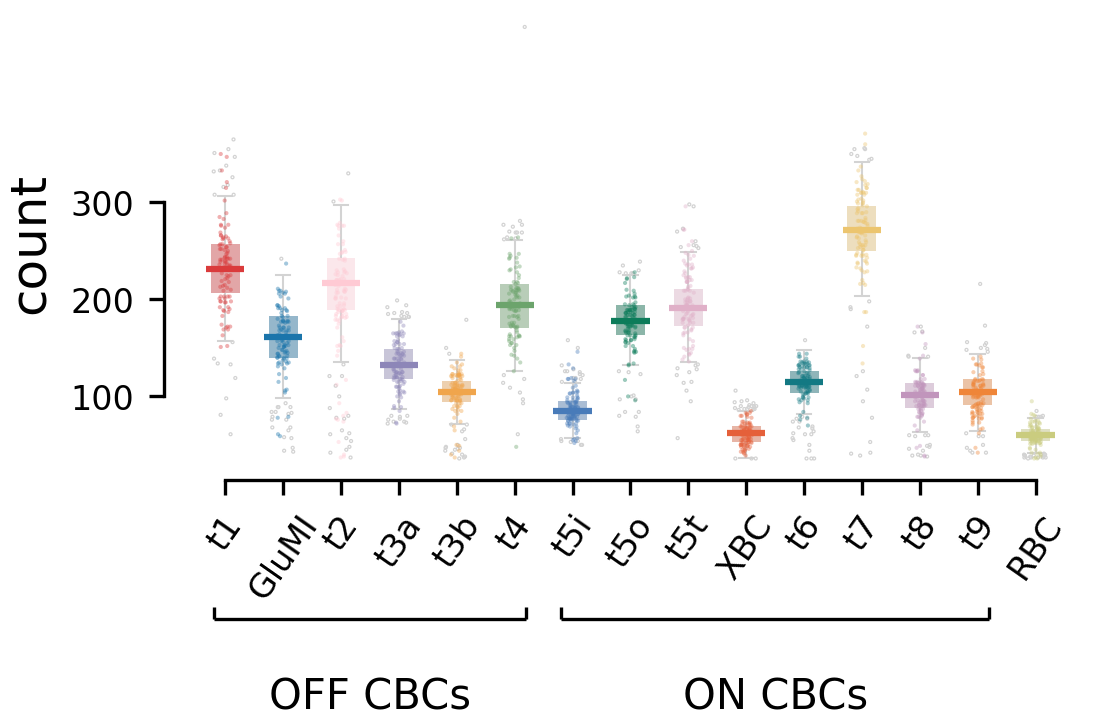

In [17]:
fig_count = plot_boxplot(
    bc_df_, 'cell_type', 'count', order,
    ylabel='count', show_points=True,
    hue='cell_type', palette=cell_type_colors,
)


fig_count.savefig(f'{fig_dir}/fig8_F_counts.svg', format = 'svg')
fig_count.savefig(f'{fig_dir}/fig8_F_counts.png', format = 'png')

### mean size per BC type

/tmp/ipykernel_2747817/938286339.py:101: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(100, len(g)), random_state=0))


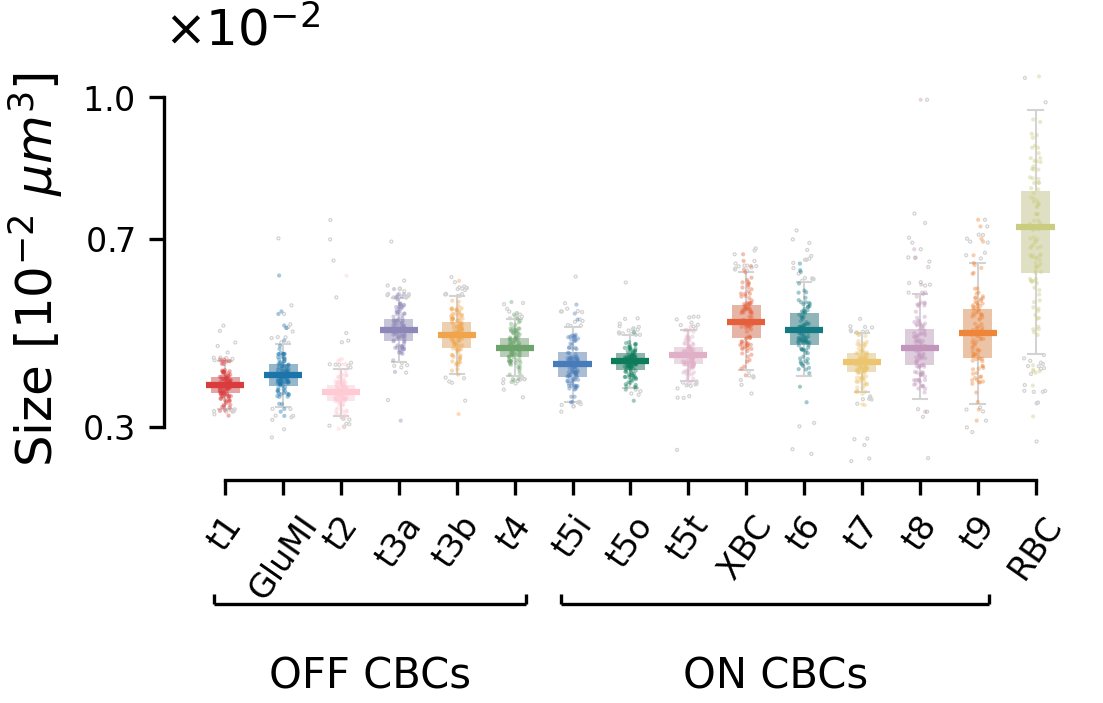

In [18]:
fig_size = plot_boxplot(
    bc_df_, 'cell_type', 'size', order,
    ylabel='size', show_points=True,
    hue='cell_type', palette=cell_type_colors,
)


fig_size.savefig(f'{fig_dir}/fig8_F_size.svg', format = 'svg')
fig_size.savefig(f'{fig_dir}/fig8_F_size.png', format = 'png')

## figure S1

### distribution of ribbon count per BC type

/gpfs01/berens/user/sebert/Repositories/eyewire2-figures/.venv/lib/python3.13/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/gpfs01/berens/user/sebert/Repositories/eyewire2-figures/.venv/lib/python3.13/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/gpfs01/berens/user/sebert/Repositories/eyewire2-figures/.venv/lib/python3.13/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/gpfs01/berens/user/sebert/Repositories/eyewire2-figures/.venv/lib/python3.13/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight 

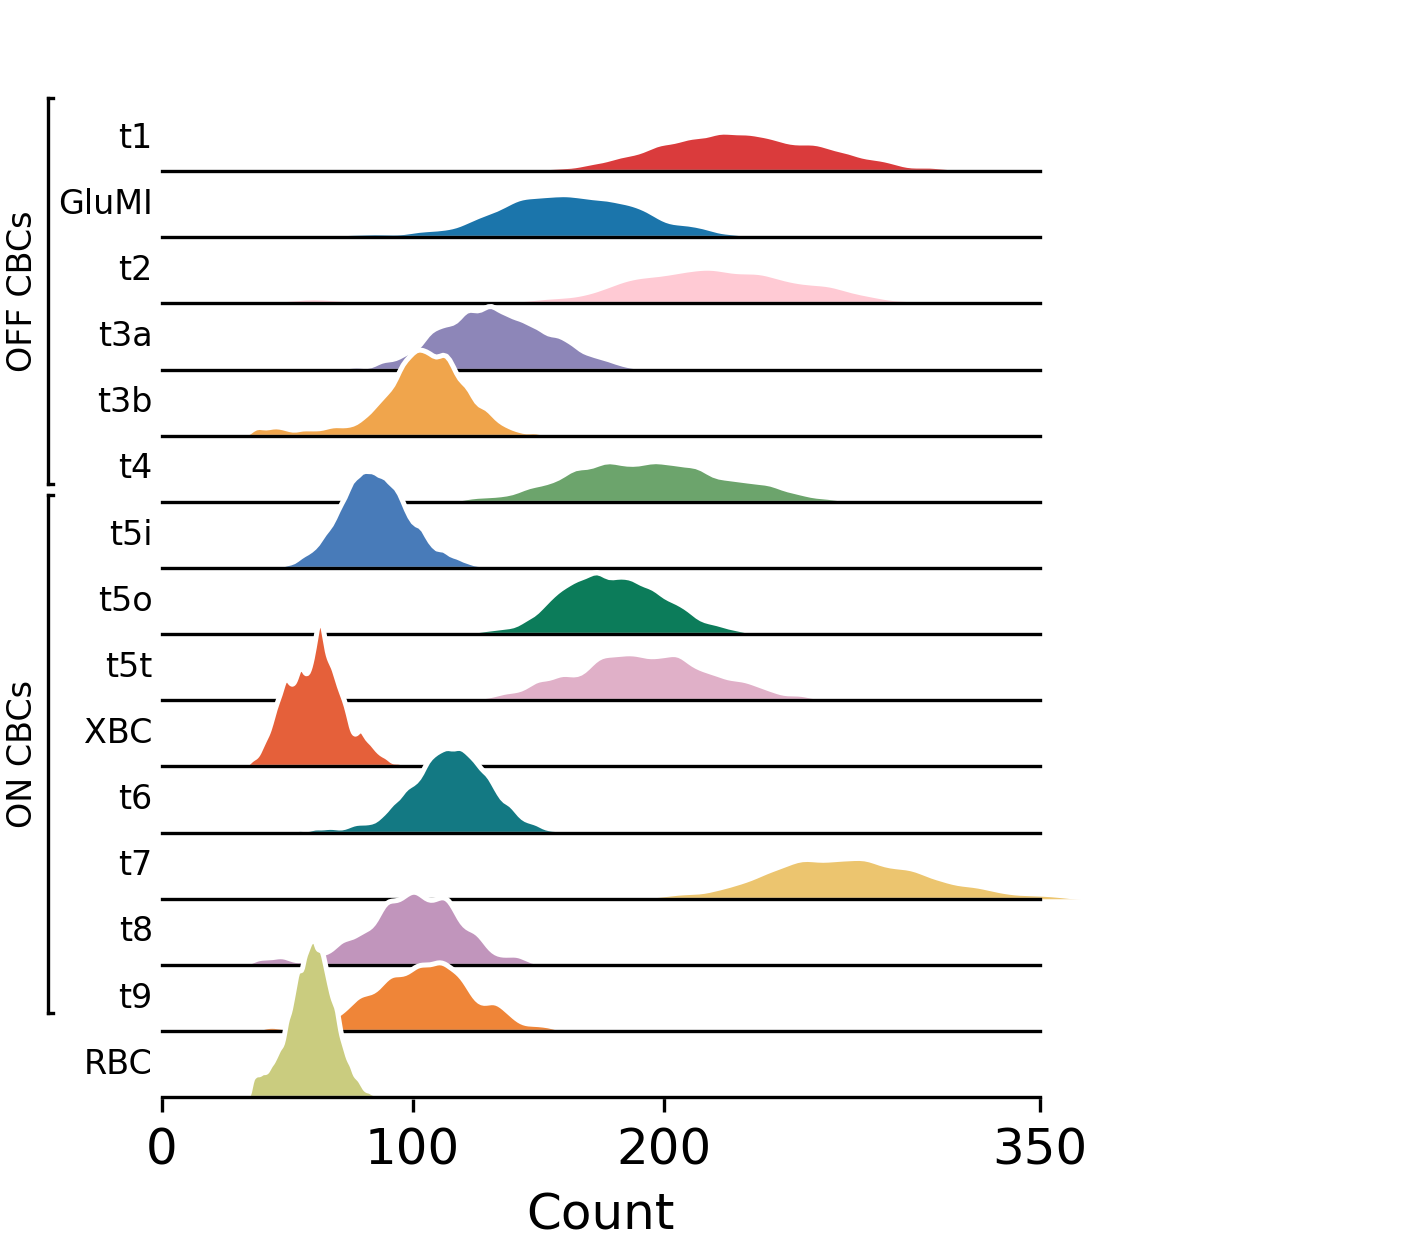

In [19]:
order = list(reversed(order))


fig_count = plot_ridgeplot(
    bc_df_, x='cell_type', y='count',
    order=order, xlabel='Count',
    xlim=(0, 350),
    xticks=[0, 100, 200, 350],
    xticklabels=['0', '100', '200', '350'],
)


fig_count.savefig(f'{fig_dir}/figS1_counts_ridge.svg', format = 'svg')
fig_count.savefig(f'{fig_dir}/figS1_counts_ridge.png', format = 'png')

### distribution of mean ribbon size per BC type

/gpfs01/berens/user/sebert/Repositories/eyewire2-figures/.venv/lib/python3.13/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/gpfs01/berens/user/sebert/Repositories/eyewire2-figures/.venv/lib/python3.13/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/gpfs01/berens/user/sebert/Repositories/eyewire2-figures/.venv/lib/python3.13/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/gpfs01/berens/user/sebert/Repositories/eyewire2-figures/.venv/lib/python3.13/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight 

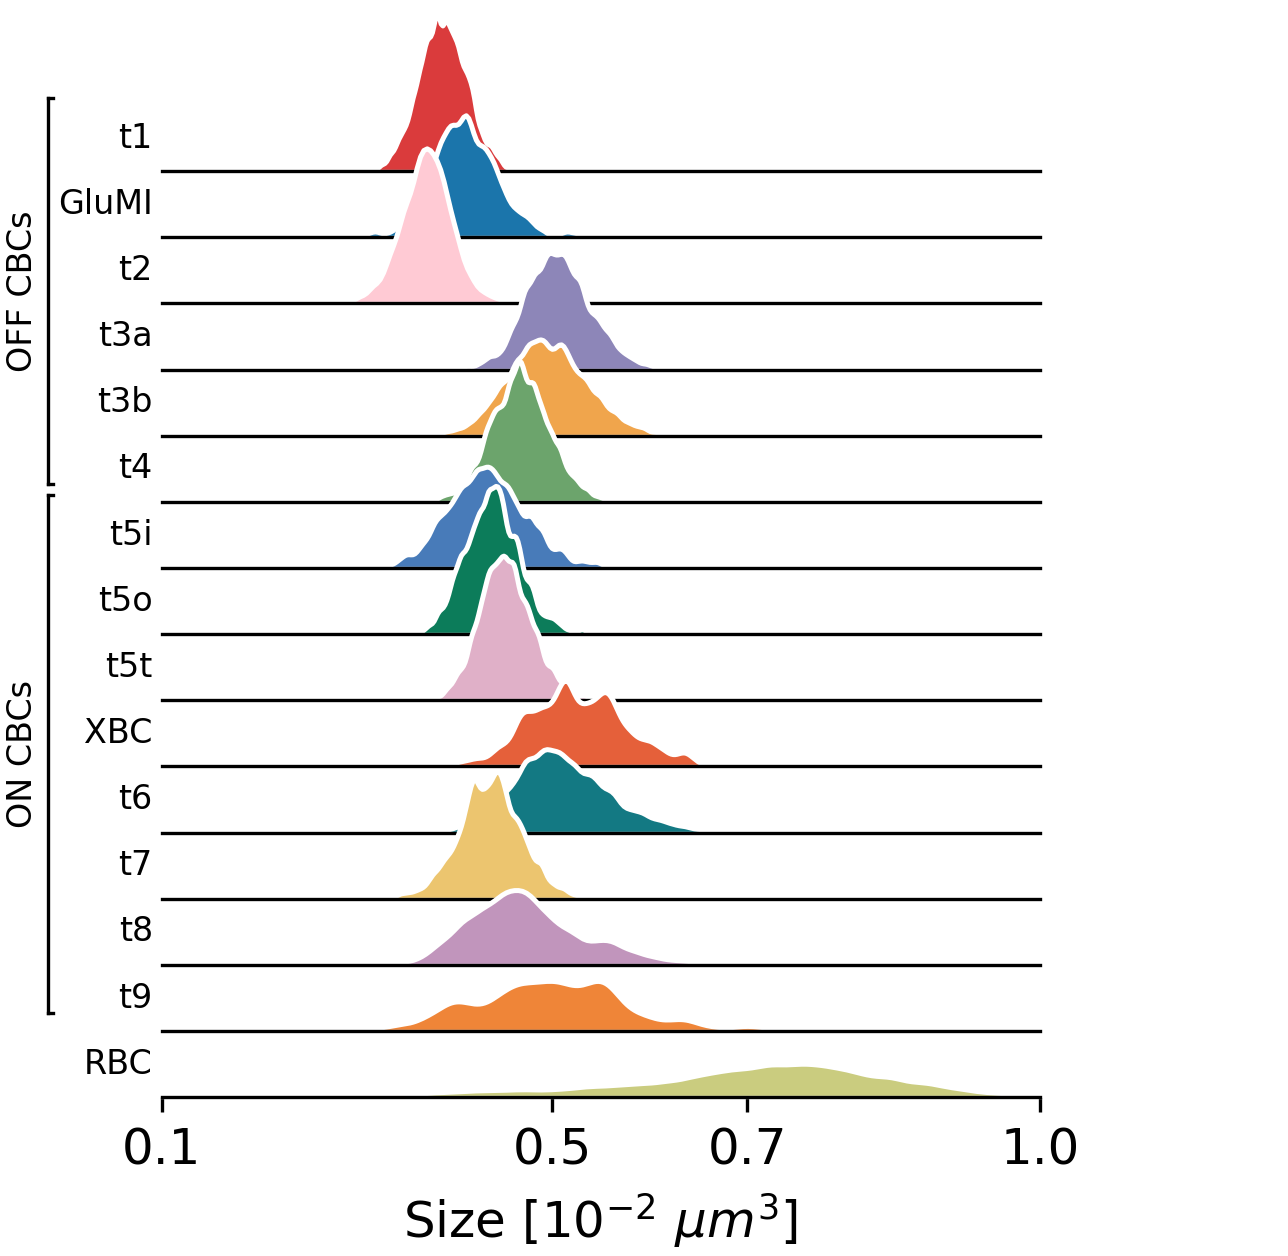

In [20]:
fig_size = plot_ridgeplot(
    bc_df_, x='cell_type', y='size',
    order=order, xlabel=r'Size $[10^{-2}\ \mu m^3]$',
    xlim=(1e-3, 1e-2),
    xticks=[1e-3, 5e-3, 7e-3, 1e-2],
    xticklabels=["0.1","0.5", "0.7", "1.0"],
)


fig_size.savefig(f'{fig_dir}/figS1_sizes_ridge.svg', format = 'svg')
fig_size.savefig(f'{fig_dir}/figS1_sizes_ridge.png', format = 'png')

# statistical testing

## unequal variance

In [21]:
# this one test wether variances are unequal, they are!
groups = [grp["count"].values for _, grp in bc_df_.groupby("cell_type")]
stat, p = levene(*groups)
print(f"Levene's test: F={stat:.4f}, p={p:.4e}")

groups = [grp["size"].values for _, grp in bc_df_.groupby("cell_type")]
stat, p = levene(*groups)
print(f"Levene's test: F={stat:.4f}, p={p:.4e}")

Levene's test: F=789.0461, p=0.0000e+00
Levene's test: F=1288.4346, p=0.0000e+00


## welch anova

In [22]:

result = welch_anova(data=bc_df_, dv="count", between="cell_type")  # see https://pingouin-stats.org/generated/pingouin.welch_anova.html
print('-------- count--------------')
print(result)

-------- count--------------
      Source  ddof1        ddof2             F  p_unc       np2
0  cell_type     14  6637.583228  17434.380327    0.0  0.854233


In [23]:
result = welch_anova(data=bc_df_, dv="size", between="cell_type")  # see https://pingouin-stats.org/generated/pingouin.welch_anova.html
print('-------- size--------------')
print(result)

-------- size--------------
      Source  ddof1        ddof2            F  p_unc       np2
0  cell_type     14  6965.068717  5413.549655    0.0  0.678111


## pairwise comparison

In [24]:
results_count_alternative = pairwise_gameshowell(data=bc_df_, dv='count', between= 'cell_type', effsize='cohen')
results_size_alternative = pairwise_gameshowell(data=bc_df_, dv='size', between= 'cell_type', effsize='cohen')

### figure S2 : pairwise p-values and effect sizes

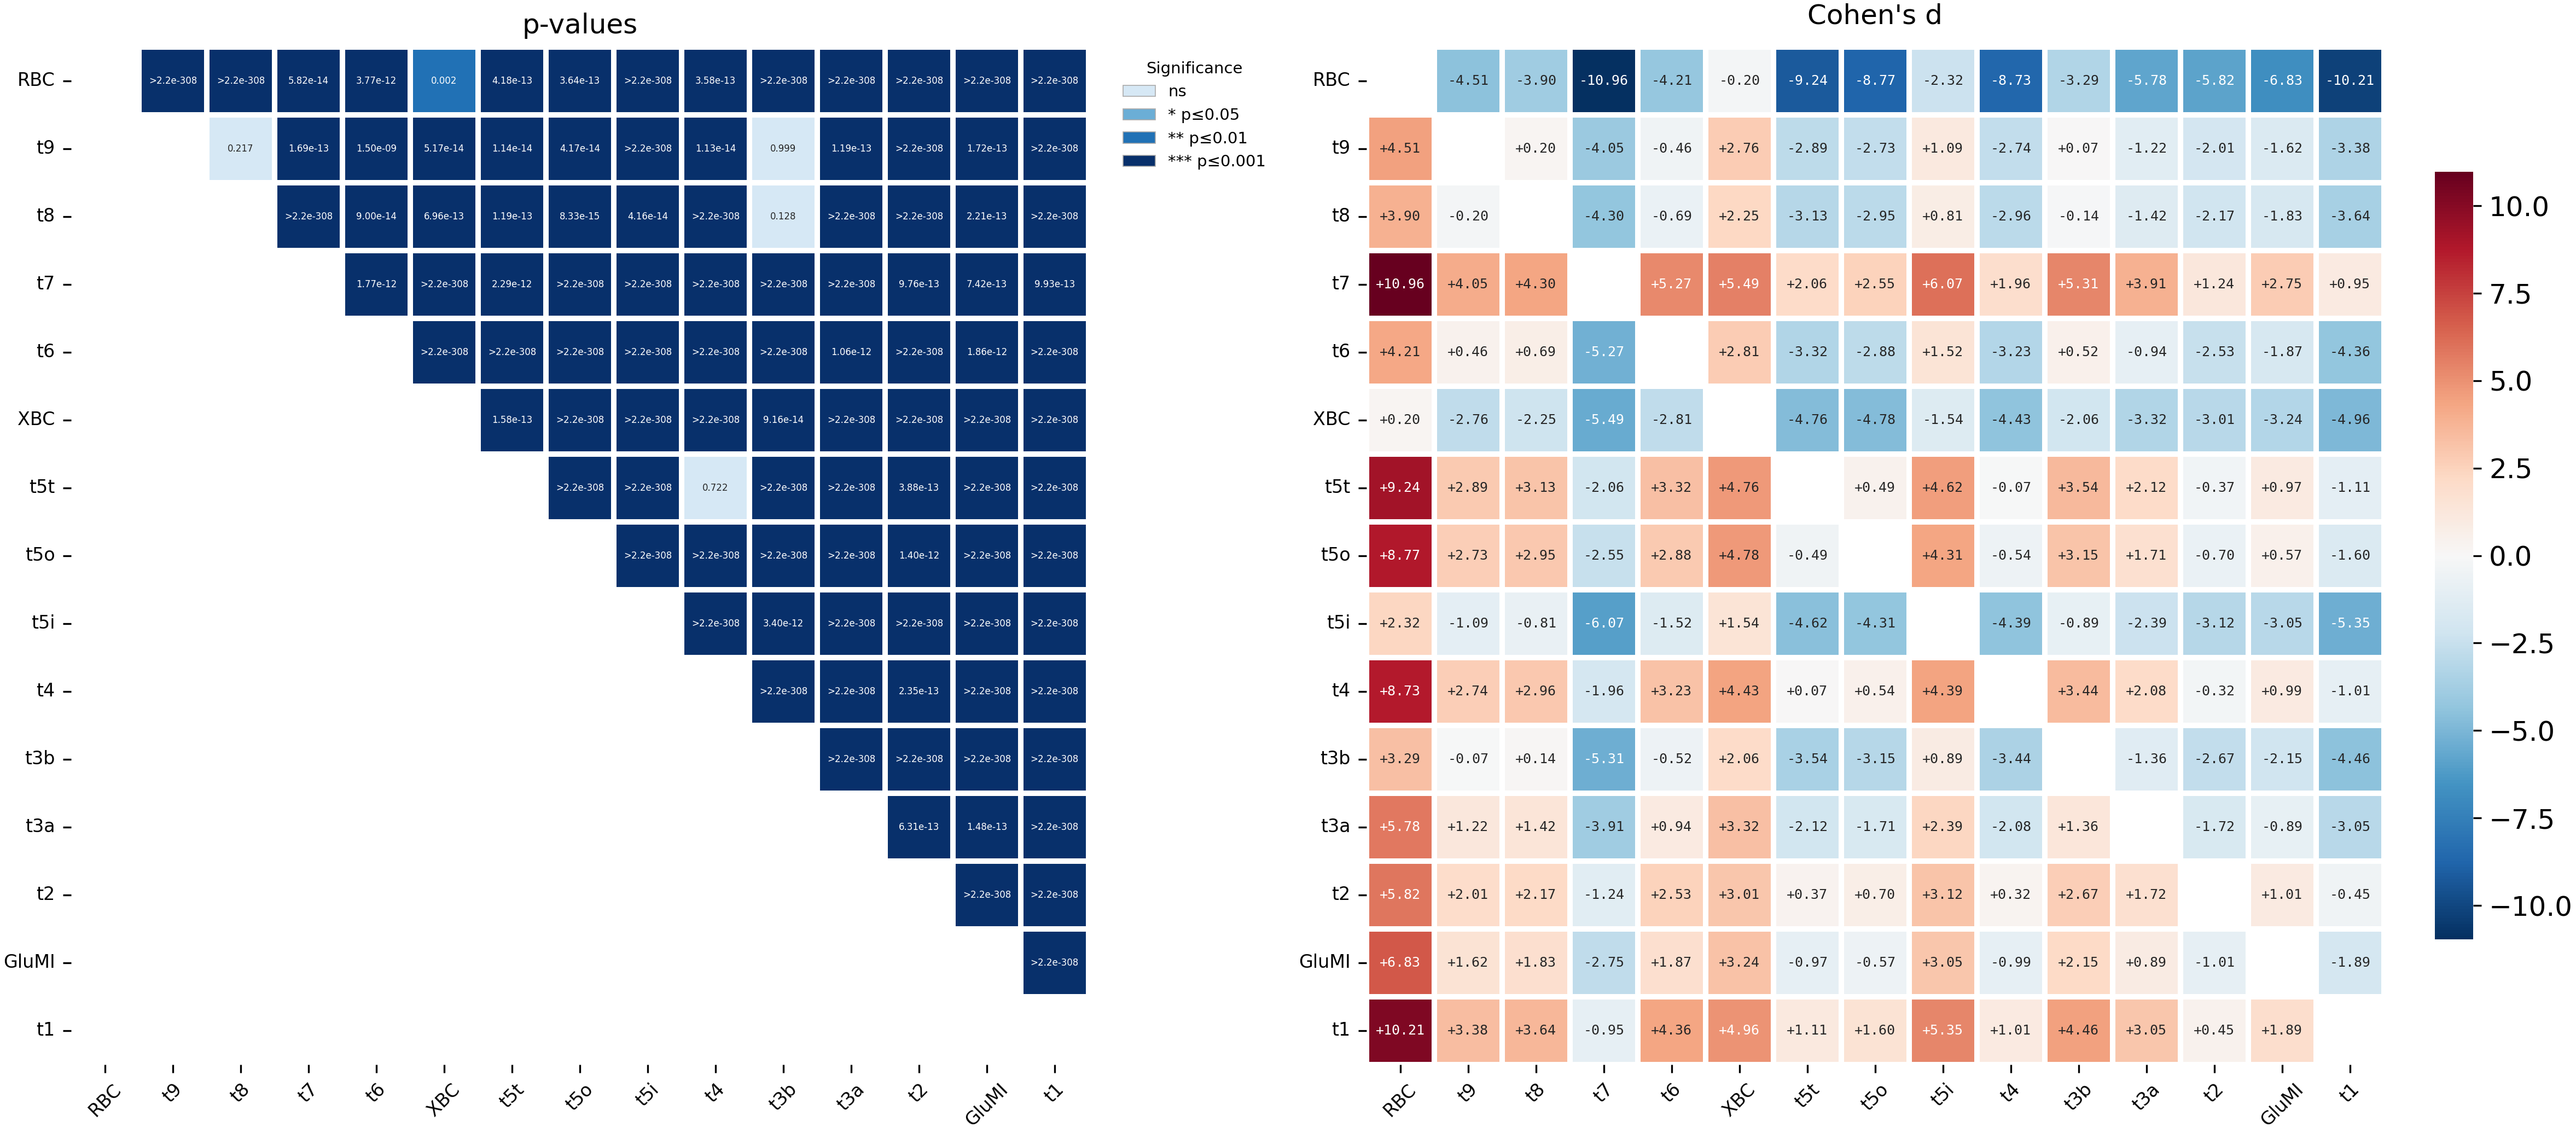

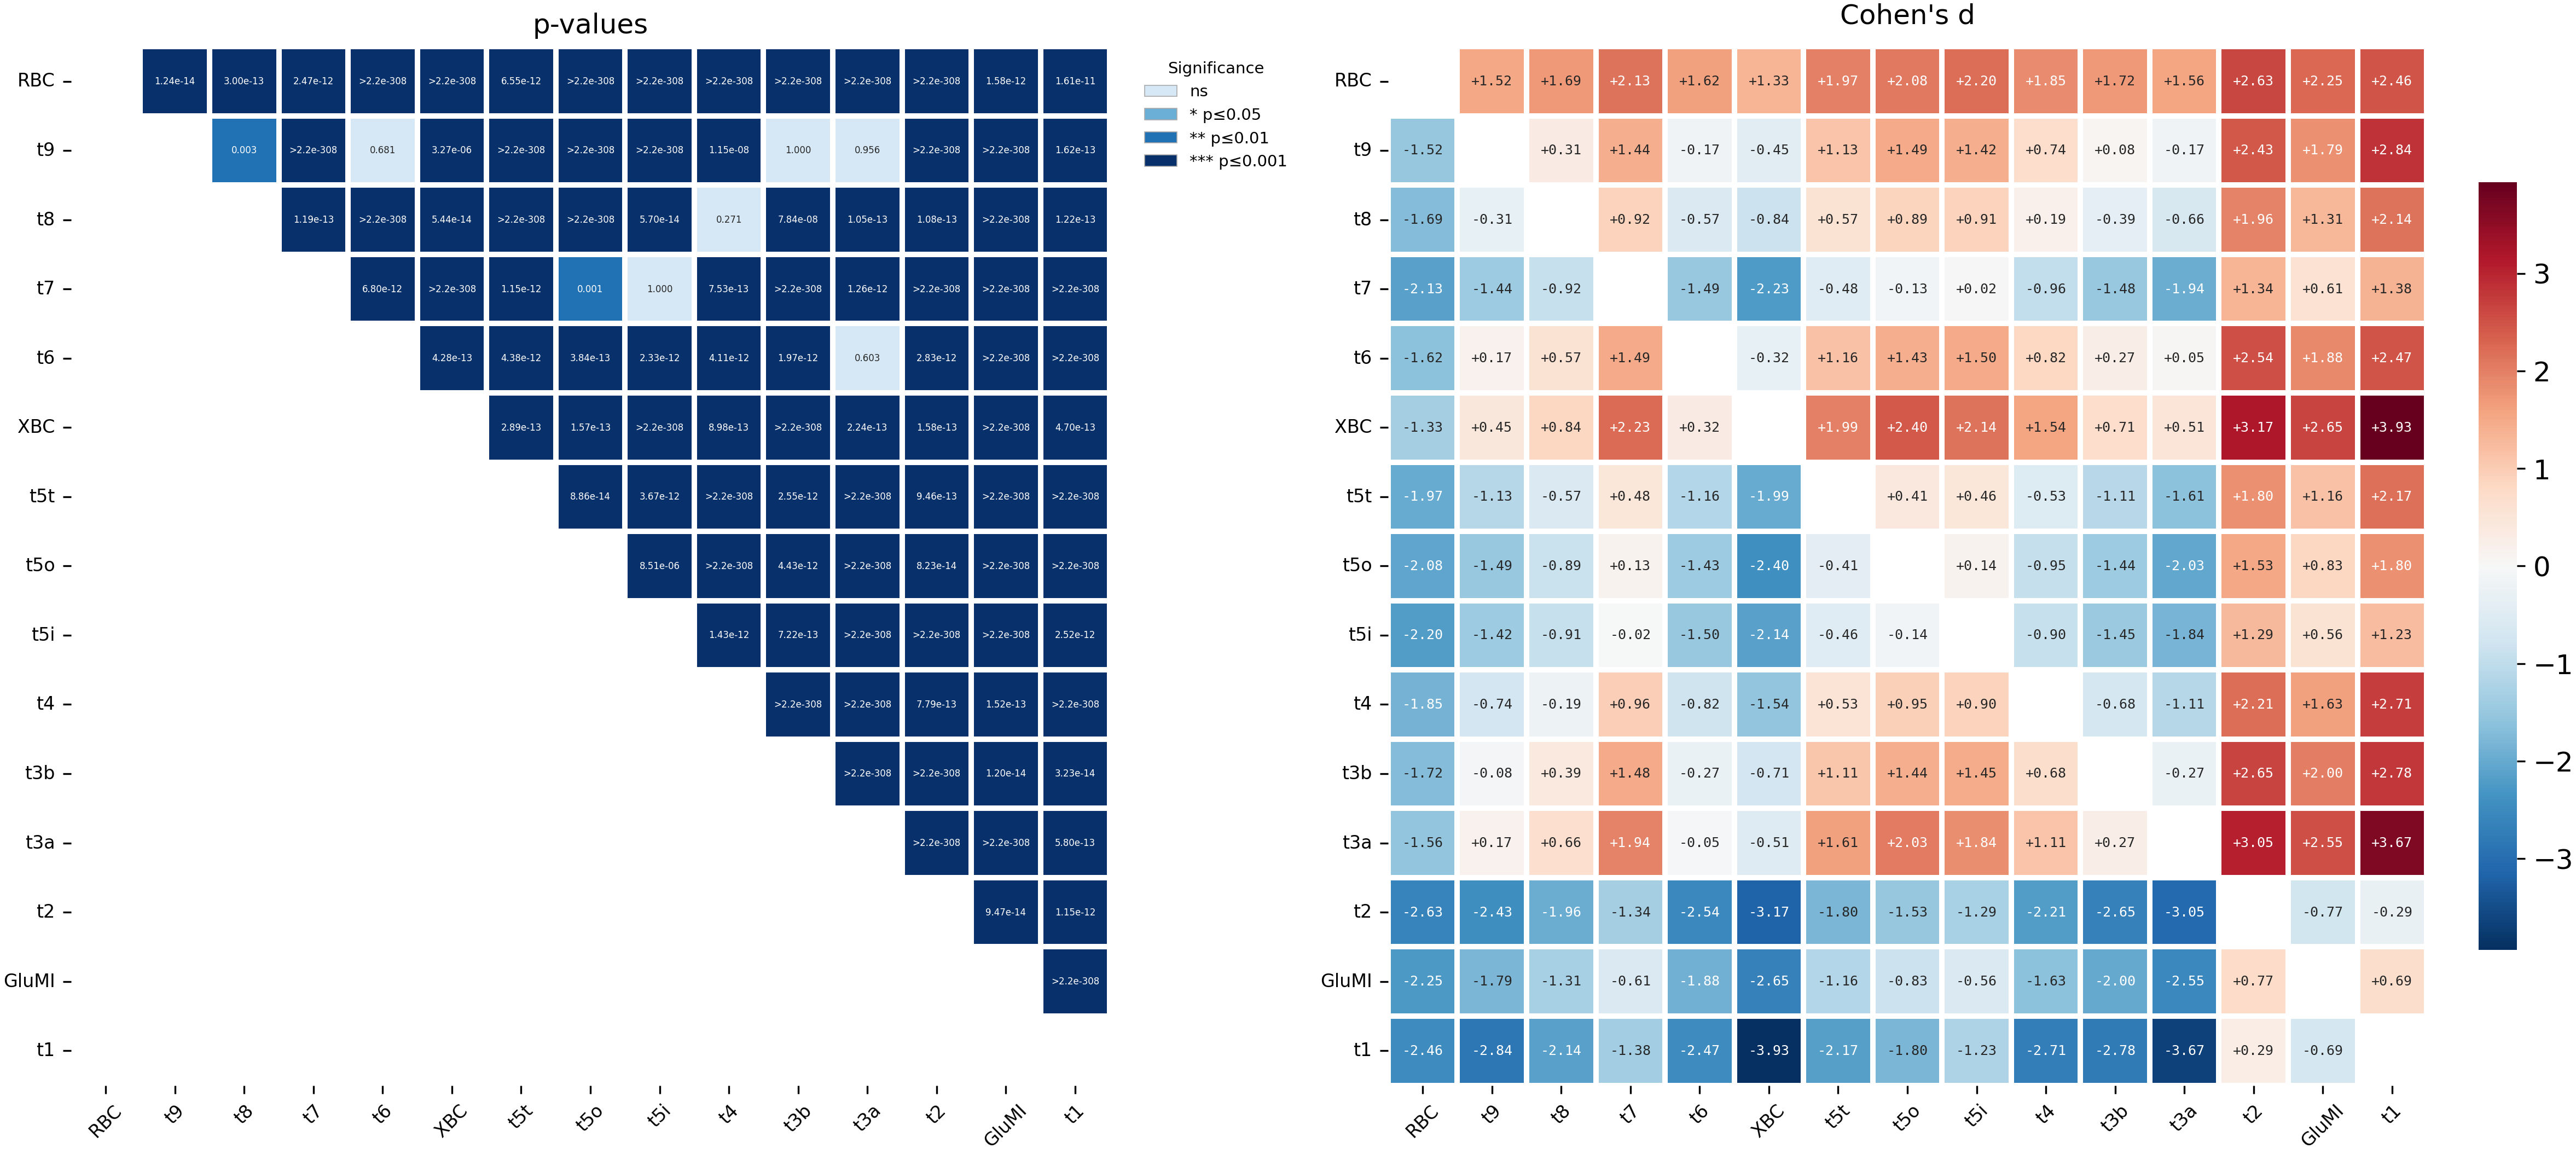

In [25]:
fig_stats_count = make_figure(results_count_alternative, "IPL count", "panels/FigureS6_stats_IPL_count_.svg", order)
fig_stats_size = make_figure(results_size_alternative,  "Cell size",  "panels/FigureS6_stats_size_.svg", order)

fig_stats_count.savefig(f"{fig_dir}/figS2_stats_IPL_count.svg")
fig_stats_size.savefig(f"{fig_dir}/figS2_stats_size.svg")

fig_stats_count.savefig(f"{fig_dir}/figS2_stats_IPL_count.png")
fig_stats_size.savefig(f"{fig_dir}/figS2_stats_size.png")